# 04 — EDA: DB1B Fare Data

BTS Origin and Destination Survey — 10% sample of airline tickets sold by US reporting carriers.
Granularity: one row per market (one direction of an itinerary), one quarter.

**Scope:** Domestic US only — both origin and destination are US airports. International fares (e.g. IAD→LHR) are not captured here; use T-100 for international traffic volume.

**Coverage:** 2015 Q1 – 2025 Q2 (Q3/Q4 2025 and 2026 not yet published by BTS at time of download).

**Key columns:**
- `MktFare` — fare for this market (one direction); the core price signal
- `MktCoupons` — number of flight segments: 1=nonstop, 2=one-stop, 3+=multi-stop
- `Passengers` — passengers on this ticket (10% sample weight not applied here)
- `BulkFare` — 1 if a group/bulk fare (unreliable pricing, excluded from analysis)
- `TkCarrier` — ticketing carrier (who sold the ticket)
- `NonStopMiles` — great-circle distance between origin and destination

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import sys

PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from config import PROCESSED_DATA_PATH

sns.set_theme(style='whitegrid', palette='muted')
AIRPORTS = ['IAD', 'DCA', 'BWI']
AIRPORT_NAMES = {'IAD': 'Dulles (IAD)', 'DCA': 'Reagan (DCA)', 'BWI': 'BWI'}
COLORS = {'IAD': '#1f77b4', 'DCA': '#ff7f0e', 'BWI': '#2ca02c'}

df = pd.read_parquet(PROJECT_ROOT / PROCESSED_DATA_PATH / 'db1b_dmv.parquet')

# Working dataset: exclude bulk fares and zero-fare records
fare = df[(df['BulkFare'] == 0) & (df['MktFare'] > 0)].copy()

print(f'Total rows: {len(df):,}')
print(f'After bulk/zero exclusion: {len(fare):,}  ({len(fare)/len(df)*100:.1f}% retained)')
print(f'Year range: {df["Year"].min()} Q{df[df["Year"]==df["Year"].min()]["Quarter"].min()}',
      f'to {df["Year"].max()} Q{df[df["Year"]==df["Year"].max()]["Quarter"].max()}')
print()
print('MktCoupons (flight segments per market):')
print(df['MktCoupons'].value_counts().sort_index().rename({1:'1 nonstop',2:'2 one-stop',3:'3 two-stop'}))

Total rows: 19,936,926
After bulk/zero exclusion: 19,811,058  (99.4% retained)


Year range: 2015 Q1 to 2025 Q2

MktCoupons (flight segments per market):
MktCoupons
1 nonstop     12398551
2 one-stop     7074670
3 two-stop      430465
4                29891
5                 2879
6                  354
7                   96
8                   10
9                    7
10                   2
11                   1
Name: count, dtype: int64


## 1. Fare distribution by airport

All outbound markets (Origin in airports), non-bulk, MktFare > 0.

C:\Users\kabec\AppData\Local\Temp\ipykernel_49740\2257808536.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_airport, labels=[AIRPORT_NAMES[a] for a in AIRPORTS],


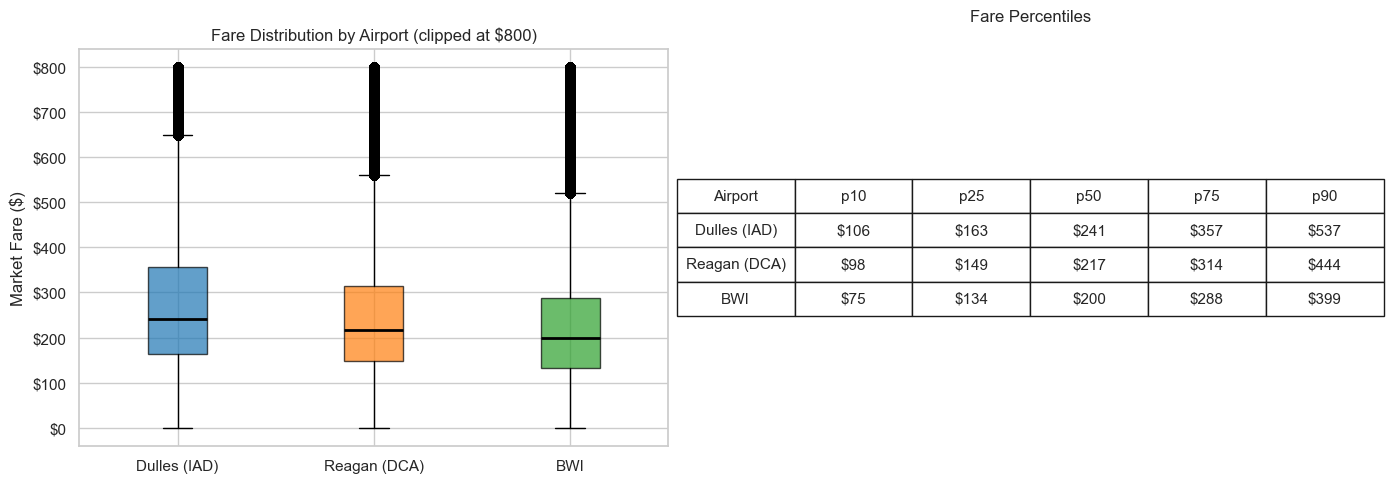

In [2]:
outbound = fare[fare['Origin'].isin(AIRPORTS)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ax = axes[0]
data_by_airport = [outbound[outbound['Origin']==ap]['MktFare'].clip(0, 800) for ap in AIRPORTS]
bp = ax.boxplot(data_by_airport, labels=[AIRPORT_NAMES[a] for a in AIRPORTS],
                patch_artist=True, medianprops=dict(color='black', linewidth=2))
for patch, ap in zip(bp['boxes'], AIRPORTS):
    patch.set_facecolor(COLORS[ap])
    patch.set_alpha(0.7)
ax.set_title('Fare Distribution by Airport (clipped at $800)')
ax.set_ylabel('Market Fare ($)')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

# Percentile table
ax = axes[1]
ax.axis('off')
pcts = [10, 25, 50, 75, 90]
rows = []
for ap in AIRPORTS:
    sub = outbound[outbound['Origin']==ap]['MktFare']
    rows.append([AIRPORT_NAMES[ap]] + [f'${sub.quantile(p/100):.0f}' for p in pcts])
tbl = ax.table(
    cellText=rows,
    colLabels=['Airport'] + [f'p{p}' for p in pcts],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2)
ax.set_title('Fare Percentiles', pad=20)

plt.tight_layout()
plt.show()

## 2. Annual fare trends 2015–2025

Median market fare per year. BWI runs $20–45 cheaper than IAD across the entire decade.

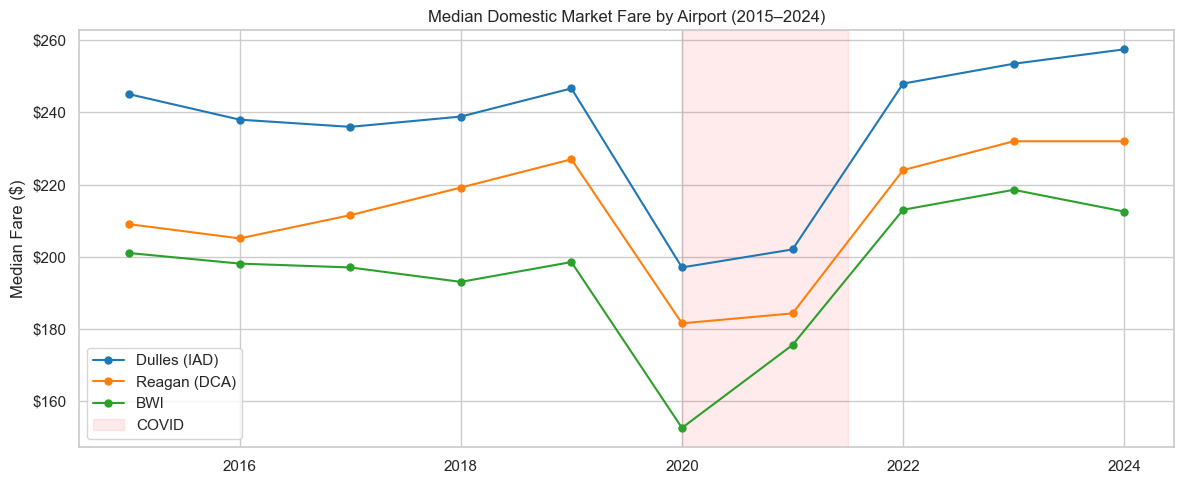

Median fare by year:
Origin   BWI   DCA   IAD
Year                    
2015    $201  $209  $245
2016    $198  $205  $238
2017    $197  $212  $236
2018    $193  $219  $239
2019    $198  $227  $247
2020    $152  $182  $197
2021    $176  $184  $202
2022    $213  $224  $248
2023    $219  $232  $254
2024    $212  $232  $258


C:\Users\kabec\AppData\Local\Temp\ipykernel_49740\413174404.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(yr_fare.applymap(lambda x: f'${x:.0f}').to_string())


In [3]:
yr_fare = (
    outbound[outbound['Year'] <= 2024]  # 2025 only Q1-Q2, partial year
    .groupby(['Year', 'Origin'])['MktFare']
    .median()
    .unstack()
)

fig, ax = plt.subplots(figsize=(12, 5))
for ap in AIRPORTS:
    ax.plot(yr_fare.index, yr_fare[ap], marker='o', ms=5,
            label=AIRPORT_NAMES[ap], color=COLORS[ap])
ax.axvspan(2020, 2021.5, alpha=0.08, color='red', label='COVID')
ax.set_title('Median Domestic Market Fare by Airport (2015–2024)')
ax.set_ylabel('Median Fare ($)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

print('Median fare by year:')
print(yr_fare.applymap(lambda x: f'${x:.0f}').to_string())

## 3. COVID fare impact indexed to 2019

Fares fell ~20% in 2020 and partially recovered in 2021. By 2022 they were back to or above 2019 levels — BWI fares are now running ~8% above pre-COVID.

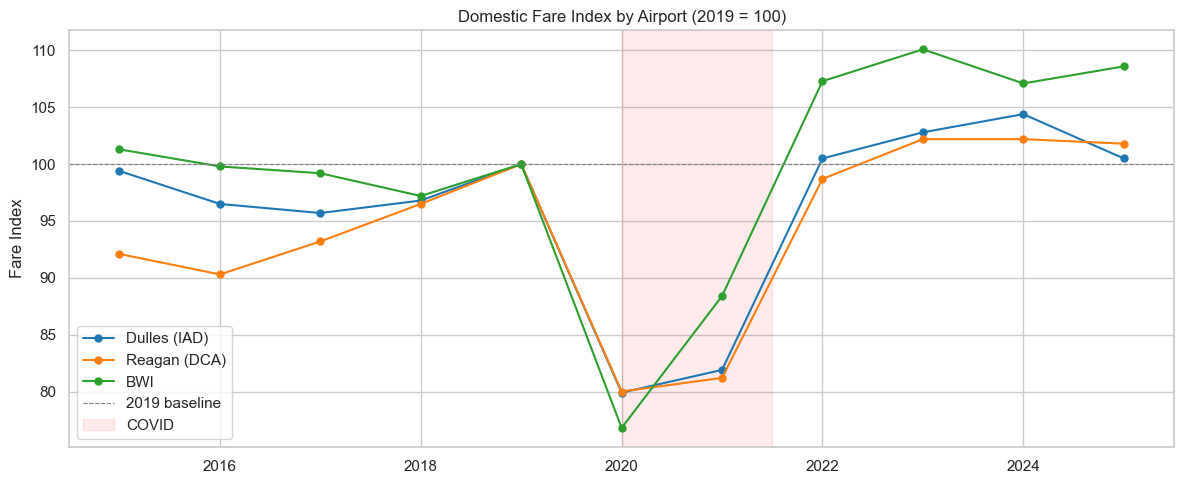

Origin    BWI    DCA    IAD
Year                       
2019    100.0  100.0  100.0
2020     76.8   80.0   79.9
2021     88.4   81.2   81.9
2022    107.3   98.7  100.5
2023    110.1  102.2  102.8
2024    107.1  102.2  104.4
2025    108.6  101.8  100.5


In [4]:
yr_all = (
    outbound
    .groupby(['Year', 'Origin'])['MktFare']
    .median()
    .unstack()
)
base_2019 = yr_all.loc[2019]
indexed = (yr_all / base_2019 * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
for ap in AIRPORTS:
    ax.plot(indexed.index, indexed[ap], marker='o', ms=5,
            label=AIRPORT_NAMES[ap], color=COLORS[ap])
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8, label='2019 baseline')
ax.axvspan(2020, 2021.5, alpha=0.08, color='red', label='COVID')
ax.set_title('Domestic Fare Index by Airport (2019 = 100)')
ax.set_ylabel('Fare Index')
ax.set_xlabel('')
ax.legend()
plt.tight_layout()
plt.show()

print(indexed.loc[2019:].to_string())

## 4. Nonstop vs connecting fares

Nonstop tickets are consistently *cheaper* than one-stop — counterintuitive but explainable: nonstop routes exist on high-frequency, competitive corridors (IAD→LAX, DCA→BOS) where fares are driven down by competition. Routes requiring a connection tend to be thinner markets with less price competition, so the fare for that origin-destination pair is higher regardless of the stop.

C:\Users\kabec\AppData\Local\Temp\ipykernel_49740\2058316384.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=['Nonstop', 'One-stop', 'Two-stop'],


C:\Users\kabec\AppData\Local\Temp\ipykernel_49740\2058316384.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=['Nonstop', 'One-stop', 'Two-stop'],


C:\Users\kabec\AppData\Local\Temp\ipykernel_49740\2058316384.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=['Nonstop', 'One-stop', 'Two-stop'],


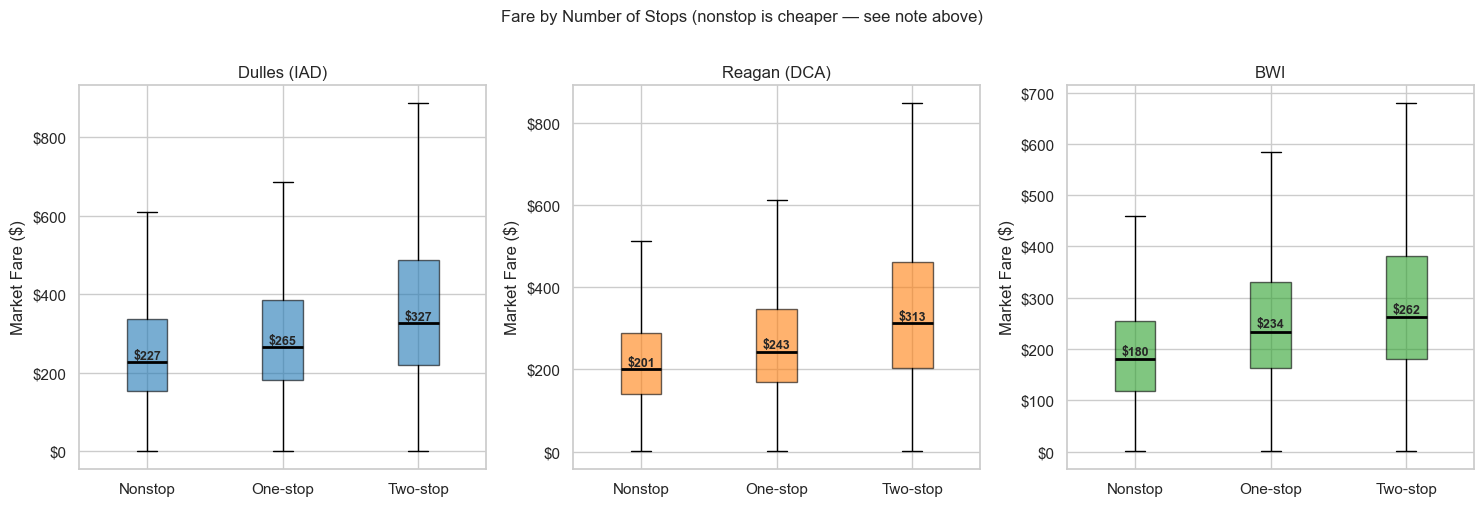

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, ap in zip(axes, AIRPORTS):
    sub = outbound[(outbound['Origin'] == ap) & (outbound['MktCoupons'] <= 3)]
    coupon_labels = {1: 'Nonstop', 2: 'One-stop', 3: 'Two-stop'}
    groups = [sub[sub['MktCoupons'] == c]['MktFare'].clip(0, 1000) for c in [1, 2, 3]]
    medians = [g.median() for g in groups]

    bp = ax.boxplot(groups, labels=['Nonstop', 'One-stop', 'Two-stop'],
                    patch_artist=True, medianprops=dict(color='black', linewidth=2),
                    showfliers=False)
    for patch in bp['boxes']:
        patch.set_facecolor(COLORS[ap])
        patch.set_alpha(0.6)
    for i, med in enumerate(medians):
        ax.text(i + 1, med + 8, f'${med:.0f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(AIRPORT_NAMES[ap])
    ax.set_ylabel('Market Fare ($)')
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

fig.suptitle('Fare by Number of Stops (nonstop is cheaper — see note above)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 5. Fare vs distance

Fares rise with distance but not linearly — the <500mi short-haul market has its own pricing dynamics, and ultra-long routes (3000+ mi, transcontinental) command a notable premium.

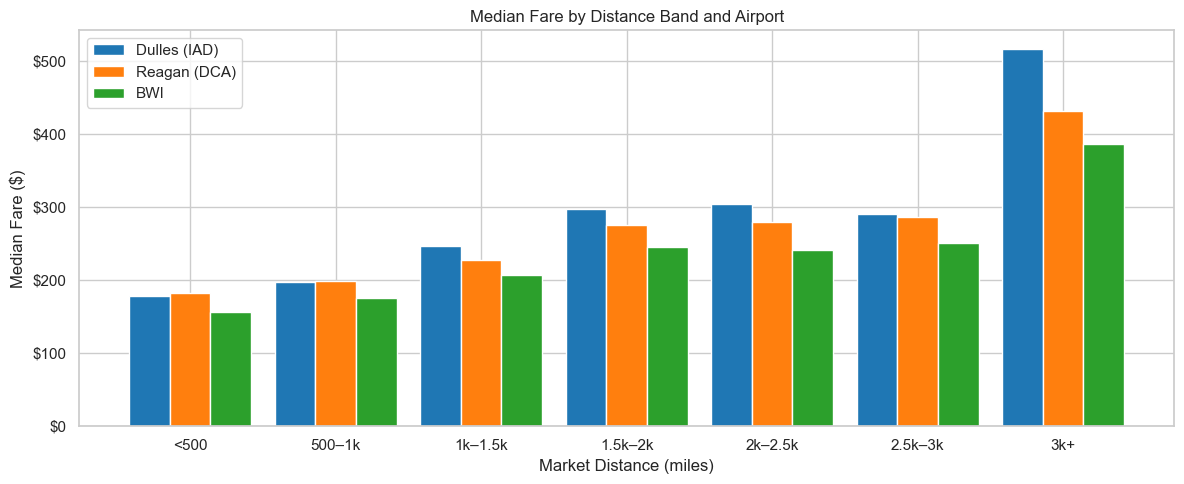

In [6]:
dist_bins = [0, 500, 1000, 1500, 2000, 2500, 3000, 9999]
dist_labels = ['<500', '500–1k', '1k–1.5k', '1.5k–2k', '2k–2.5k', '2.5k–3k', '3k+']

outbound = outbound.copy()
outbound['DistBucket'] = pd.cut(outbound['MktDistance'], bins=dist_bins, labels=dist_labels)

dist_fare = (
    outbound
    .groupby(['DistBucket', 'Origin'], observed=True)['MktFare']
    .median()
    .unstack()
)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(dist_labels))
width = 0.28
for i, ap in enumerate(AIRPORTS):
    ax.bar([xi + i * width for xi in x], dist_fare[ap], width,
           label=AIRPORT_NAMES[ap], color=COLORS[ap])
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(dist_labels)
ax.set_title('Median Fare by Distance Band and Airport')
ax.set_xlabel('Market Distance (miles)')
ax.set_ylabel('Median Fare ($)')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 6. Top routes by ticket volume per airport

Reflects what passengers actually buy, not just what airlines operate. Shows the dominant travel patterns at each airport.

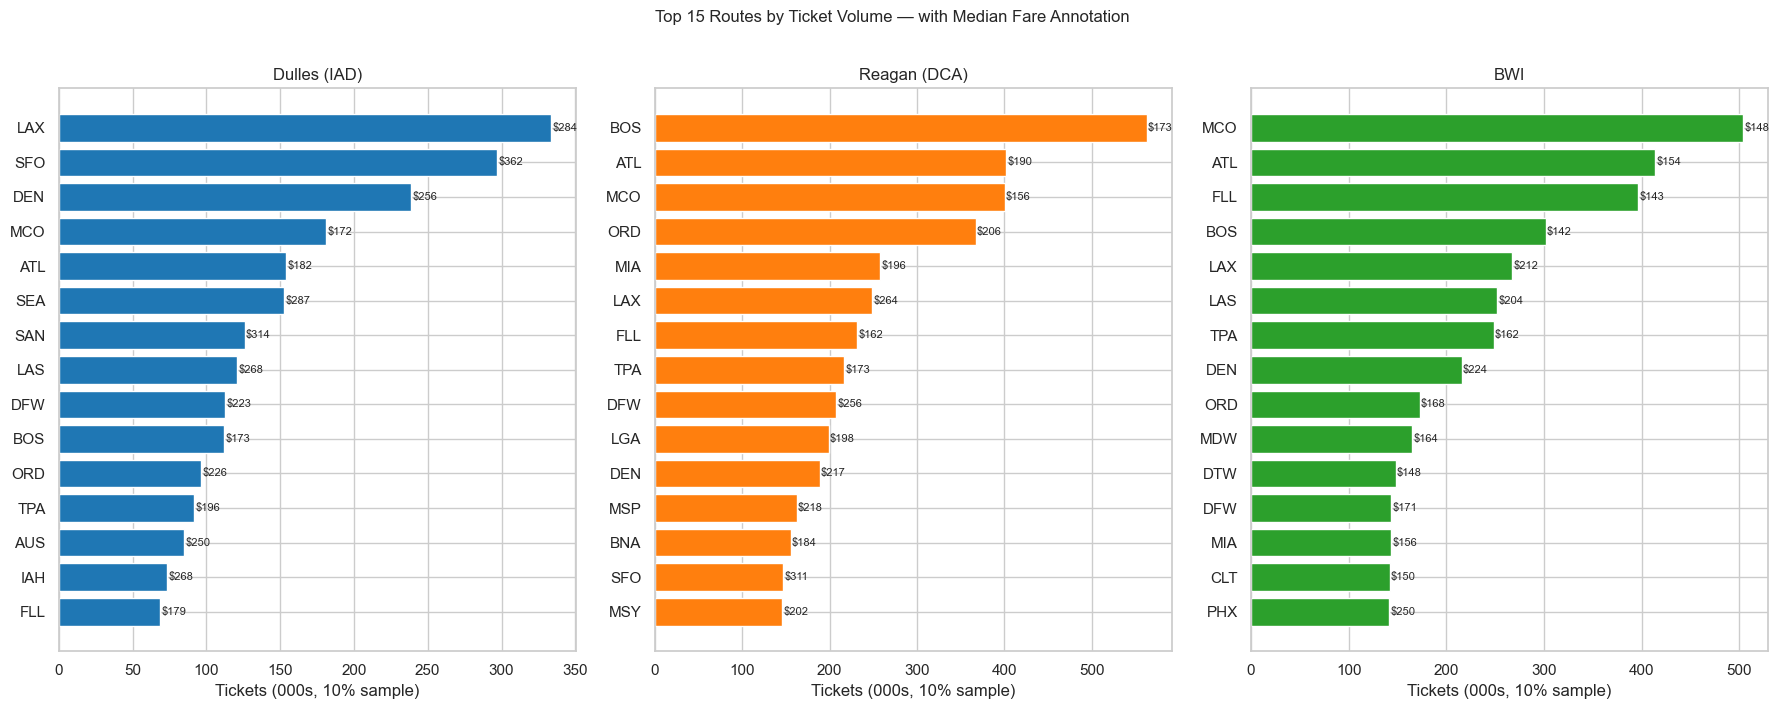

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, ap in zip(axes, AIRPORTS):
    sub = outbound[outbound['Origin'] == ap]
    top = (
        sub.groupby('Dest')
        .agg(tickets=('Passengers', 'sum'), med_fare=('MktFare', 'median'))
        .sort_values('tickets', ascending=False)
        .head(15)
        .sort_values('tickets')
    )
    bars = ax.barh(top.index, top['tickets'] / 1e3, color=COLORS[ap])
    # Annotate with median fare
    for bar, fare_val in zip(bars, top['med_fare']):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                f'${fare_val:.0f}', va='center', fontsize=8)
    ax.set_title(AIRPORT_NAMES[ap])
    ax.set_xlabel('Tickets (000s, 10% sample)')

fig.suptitle('Top 15 Routes by Ticket Volume — with Median Fare Annotation', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 7. Carrier fare comparison by airport

Ultra-low-cost carriers (Frontier, Spirit, Allegiant) price well below legacy and hybrid carriers. Alaska and United tend to be the priciest at DMV airports.

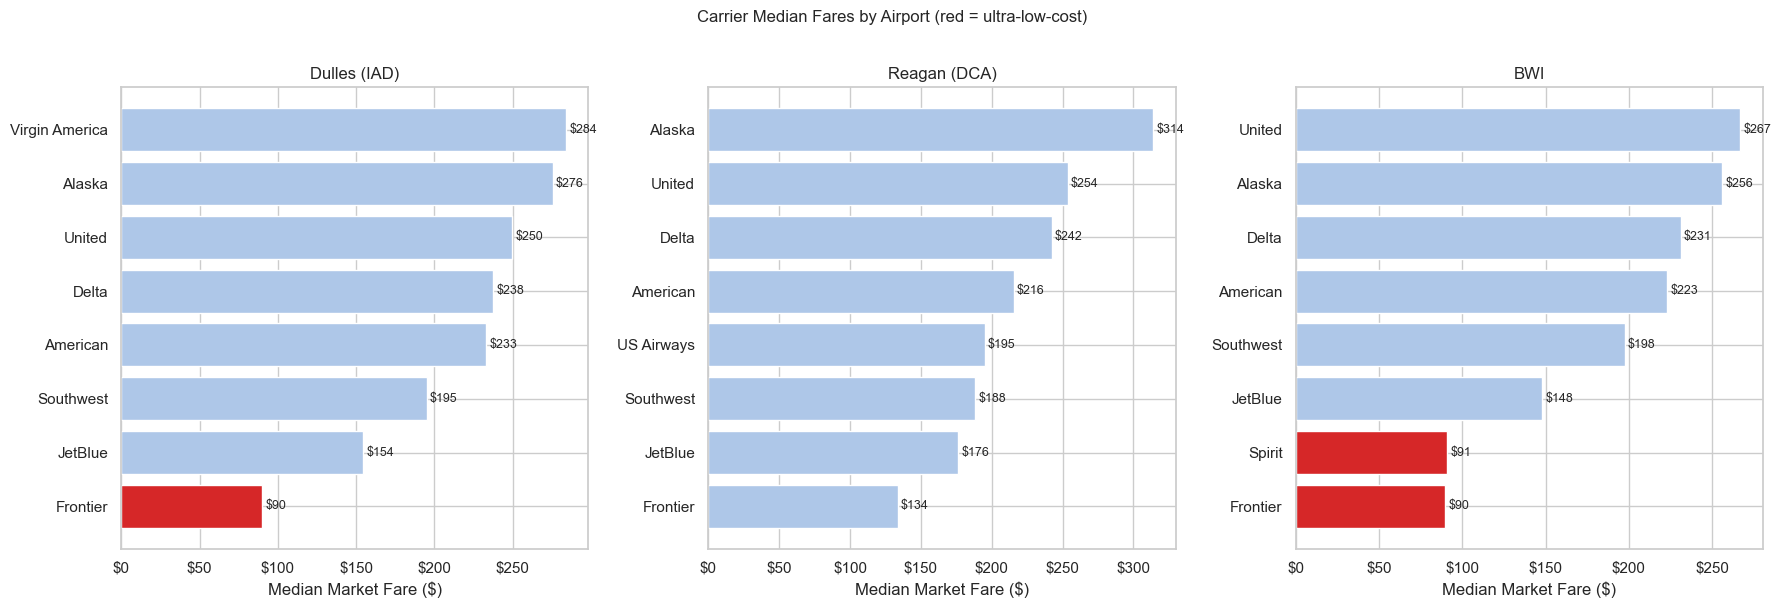

In [8]:
CARRIER_NAMES = {
    'AA': 'American', 'WN': 'Southwest', 'DL': 'Delta', 'UA': 'United',
    'B6': 'JetBlue', 'AS': 'Alaska', 'F9': 'Frontier', 'NK': 'Spirit',
    'G4': 'Allegiant', 'VX': 'Virgin America', 'US': 'US Airways',
    'YX': 'Republic', 'SY': 'Sun Country', 'HA': 'Hawaiian',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, ap in zip(axes, AIRPORTS):
    sub = outbound[outbound['Origin'] == ap]
    # Top 8 by ticket volume, mapped to readable names, exclude code '99'
    sub = sub[sub['TkCarrier'] != '99']
    top_carriers = (
        sub.groupby('TkCarrier')['Passengers'].sum()
        .sort_values(ascending=False)
        .head(8)
        .index.tolist()
    )
    grp = (
        sub[sub['TkCarrier'].isin(top_carriers)]
        .groupby('TkCarrier')['MktFare']
        .median()
        .rename(index=CARRIER_NAMES)
        .sort_values(ascending=True)
    )
    colors_bar = ['#d62728' if v < 120 else '#aec7e8' for v in grp.values]  # red = ULCC
    ax.barh(grp.index, grp.values, color=colors_bar)
    for i, v in enumerate(grp.values):
        ax.text(v + 2, i, f'${v:.0f}', va='center', fontsize=9)
    ax.set_title(AIRPORT_NAMES[ap])
    ax.set_xlabel('Median Market Fare ($)')
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

fig.suptitle('Carrier Median Fares by Airport (red = ultra-low-cost)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 8. Same-route fare comparison across airports

For the same nonstop destination, BWI is almost always cheapest — driven by Southwest's pricing. IAD and DCA flip depending on the route.

Destinations with nonstop service and >= 5,000 tickets at all 3 airports: 48


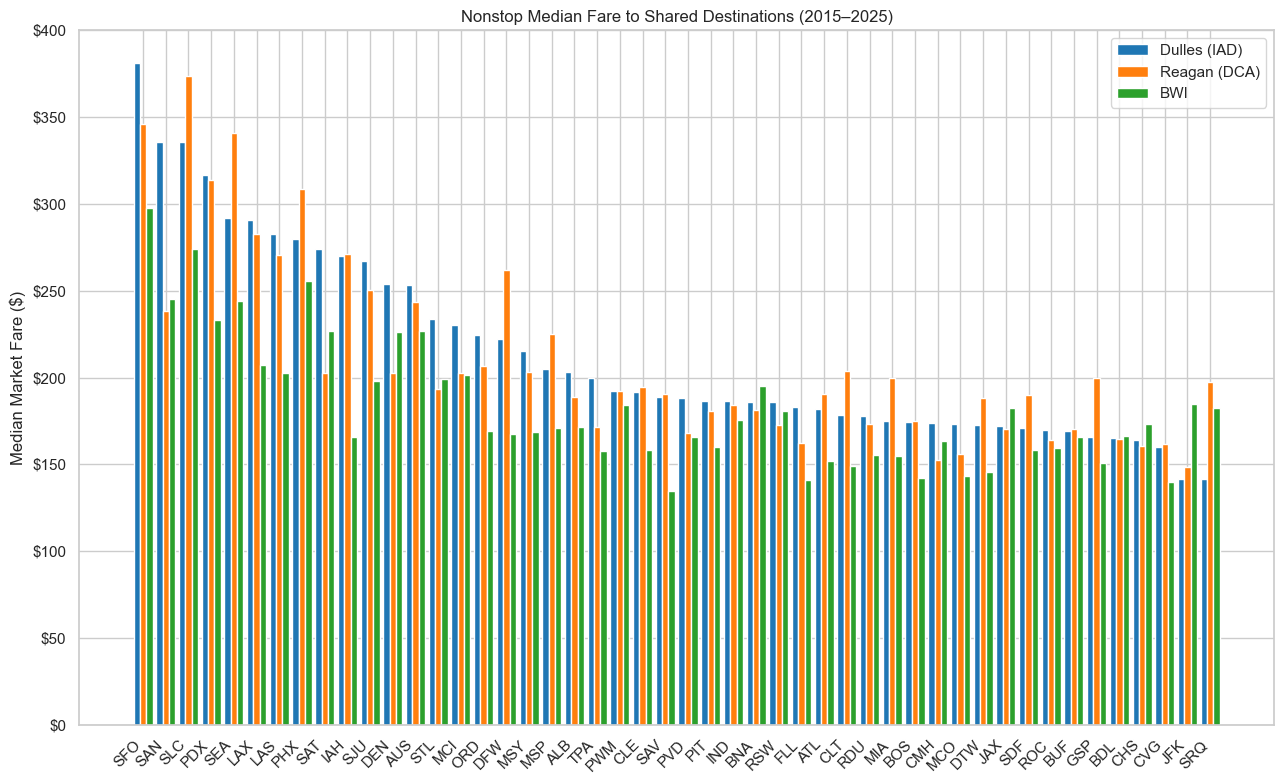


Origin     IAD      DCA      BWI cheapest  BWI saves vs IAD
Dest                                                       
SFO     381.00  346.105  298.000      BWI              83.0
SAN     336.00  238.270  245.000      DCA              91.0
SLC     335.50  374.000  274.000      BWI              62.0
PDX     316.50  314.000  233.000      BWI              84.0
SEA     292.00  341.000  244.000      BWI              48.0
LAX     291.00  283.000  207.325      BWI              84.0
LAS     282.50  270.605  202.500      BWI              80.0
PHX     280.00  308.500  255.500      BWI              24.0
SAT     274.00  202.630  227.000      DCA              47.0
IAH     270.00  271.000  166.000      BWI             104.0
SJU     267.00  250.500  198.000      BWI              69.0
DEN     254.00  202.500  226.000      DCA              28.0
AUS     253.50  243.500  227.000      BWI              26.0
STL     233.50  193.500  199.000      DCA              34.0
MCI     230.50  202.500  201.500      B

In [9]:
# Nonstop only, shared destinations with sufficient volume at all 3 airports
ns = outbound[outbound['MktCoupons'] == 1]

route_medians = (
    ns.groupby(['Origin', 'Dest'])['MktFare']
    .agg(['median', 'count'])
    .reset_index()
)

# Keep routes with >= 5000 tickets at each of the 3 airports
pivoted = route_medians.pivot(index='Dest', columns='Origin', values='median')
counts  = route_medians.pivot(index='Dest', columns='Origin', values='count')
min_tickets = 5000
shared = pivoted[(counts.min(axis=1) >= min_tickets)].dropna()
shared = shared.sort_values('IAD', ascending=False)

print(f'Destinations with nonstop service and >= {min_tickets:,} tickets at all 3 airports: {len(shared)}')

fig, ax = plt.subplots(figsize=(13, 8))
x = range(len(shared))
width = 0.28
for i, ap in enumerate(AIRPORTS):
    ax.bar([xi + i * width for xi in x], shared[ap], width,
           label=AIRPORT_NAMES[ap], color=COLORS[ap])
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(shared.index, rotation=45, ha='right')
ax.set_title('Nonstop Median Fare to Shared Destinations (2015–2025)')
ax.set_ylabel('Median Market Fare ($)')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

# Savings table: cheapest airport per route
shared['cheapest'] = shared[AIRPORTS].idxmin(axis=1)
shared['BWI_vs_IAD_savings'] = (shared['IAD'] - shared['BWI']).round(0)
print()
print(shared[['IAD','DCA','BWI','cheapest','BWI_vs_IAD_savings']]
      .rename(columns={'BWI_vs_IAD_savings': 'BWI saves vs IAD'})
      .to_string())

## 9. Quarterly seasonality

Fares show mild seasonality — Q2 (spring/summer) is the peak, Q4 (fall) the trough. The variation is small (~5%) because DMV airports carry heavy year-round business traffic that stabilizes pricing.

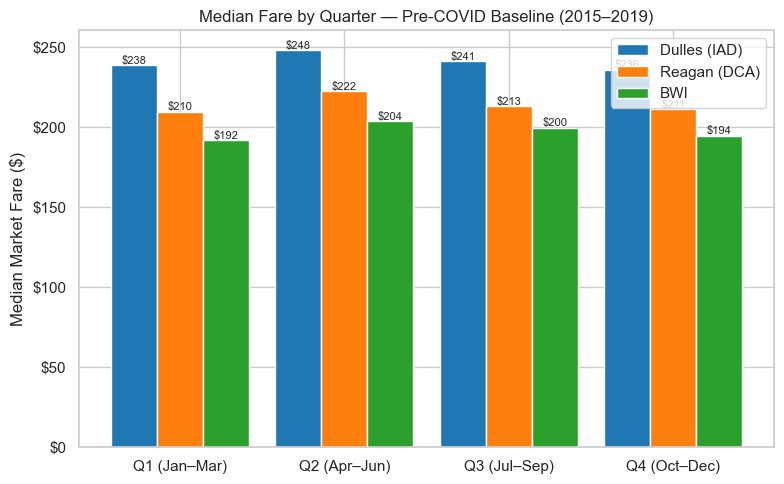

In [10]:
# Pre-COVID baseline: 2015-2019
pre = outbound[outbound['Year'].between(2015, 2019)]

q_fare = (
    pre.groupby(['Quarter', 'Origin'])['MktFare']
    .median()
    .unstack()
)

fig, ax = plt.subplots(figsize=(8, 5))
x = [1, 2, 3, 4]
width = 0.28
for i, ap in enumerate(AIRPORTS):
    ax.bar([xi + i * width for xi in x], q_fare[ap], width,
           label=AIRPORT_NAMES[ap], color=COLORS[ap])
    for xi, val in zip(x, q_fare[ap]):
        ax.text(xi + i * width, val + 1, f'${val:.0f}', ha='center', fontsize=8)
ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(['Q1 (Jan–Mar)', 'Q2 (Apr–Jun)', 'Q3 (Jul–Sep)', 'Q4 (Oct–Dec)'])
ax.set_title('Median Fare by Quarter — Pre-COVID Baseline (2015–2019)')
ax.set_ylabel('Median Market Fare ($)')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary

Key takeaways from the DB1B fare data.

In [11]:
rows = []
for ap in AIRPORTS:
    sub = outbound[outbound['Origin'] == ap]
    pre_sub = sub[sub['Year'].between(2015,2019)]
    post_sub = sub[sub['Year'].between(2023,2024)]
    rows.append({
        'Airport': AIRPORT_NAMES[ap],
        'Median fare (all)': f"${sub['MktFare'].median():.0f}",
        'Pre-COVID median': f"${pre_sub['MktFare'].median():.0f}",
        'Post-COVID median': f"${post_sub['MktFare'].median():.0f}",
        '% nonstop tickets': f"{(sub['MktCoupons']==1).mean()*100:.0f}%",
        'Nonstop median': f"${sub[sub['MktCoupons']==1]['MktFare'].median():.0f}",
        'Connecting median': f"${sub[sub['MktCoupons']==2]['MktFare'].median():.0f}",
        'Unique destinations': sub['Dest'].nunique(),
    })

summary = pd.DataFrame(rows).set_index('Airport')
print(summary.T.to_string())

Airport             Dulles (IAD) Reagan (DCA)   BWI
Median fare (all)           $241         $217  $200
Pre-COVID median            $241         $214  $198
Post-COVID median           $256         $232  $216
% nonstop tickets            66%          62%   60%
Nonstop median              $227         $201  $180
Connecting median           $265         $243  $234
Unique destinations          426          419   414
